# Knowledge Graph Features for Machine Learning

**Chapter 23: Knowledge Graphs for Financial AI** | Section 23.4

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/09_knowledge_graph_features.py
> ```


This notebook transforms the chapter's real knowledge-graph artifacts into
ML-ready features. It combines the supply chain graph loaded into Neo4j by
`02_supply_chain_kg_construction.py` with the Chapter 4 institutional holdings
parquet files to produce a feature matrix for downstream modeling.

**Learning Objectives**:
- Compute network topology features from a real supply chain graph
- Derive supplier concentration and competitive exposure indicators
- Build institutional crowding signals from real 13F holdings
- Construct cross-graph features that combine operational and ownership risk
- Output a feature matrix in wide and long formats for downstream ML

**Book Reference**: Chapter 23, Section 23.4 (From Graphs to Machine Learning Features)

**Prerequisites**: Run `02_supply_chain_kg_construction.py` first to populate Neo4j
and ensure the 13F parquet artifacts exist under `data/equities/positioning/13f`
(produced by `data/equities/positioning/13f_download.py`).

In [1]:
"""Knowledge Graph Features for Machine Learning - transform KG artifacts into ML-ready features."""

from __future__ import annotations

import os
import warnings
from hashlib import sha256
from logging import getLogger

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

from data import load_institutional_holdings_13f
from utils.paths import get_output_dir
from utils.style import add_message_title, ml4t_diverging

getLogger("matplotlib.font_manager").setLevel("ERROR")

In [2]:
# Production defaults - Papermill overrides for testing
N_COMPANIES = 0  # 0 = all available
# Point-in-time as-of date for holdings-derived features. Crowding and
# co-ownership are computed from each institution's most recent 13F filed on or
# before this date - never summed across quarters - to keep them tradable.
CUTOFF_DATE = "2026-02-17"
SUPPLY_GRAPH_COMMIT = "eacb181d"
SUPPLY_GRAPH_SHA256 = "743c96ecea2004d6ca927c7df65b02e96e67c2f84d4bb8e38d55279ceafde683"

In [3]:
OUTPUT_DIR = get_output_dir(23, "knowledge_graph_features")
print(f"Output target: {OUTPUT_DIR.name}")

Output target: ch23_knowledge_graph_features


In [4]:
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

### Name Normalization

Cross-dataset joins (supply-chain company names vs 13F issuer names) need a
canonical form. This collapses case, punctuation, and common corporate suffixes
(CORPORATION→CORP, INCORPORATED→INC) to a single comparable token.

In [5]:
def normalize_name(value: str) -> str:
    """Normalize names for cross-dataset joins."""
    aliases = {
        "LABORATORIES": "LABS",
        "LABORATORY": "LAB",
        "CORPORATION": "CORP",
        "COMPANY": "CO",
        "INCORPORATED": "INC",
    }
    tokens = []
    for token in "".join(ch if ch.isalnum() else " " for ch in value.upper()).split():
        tokens.append(aliases.get(token, token))
    return "".join(tokens)

## 1. Load the Real Supply Chain Graph

Pull the supply chain graph directly from Neo4j. The notebook requires the
real graph built in the previous case-study notebook rather than constructing
a synthetic network inline.

In [6]:
COMPANY_QUERY = """
MATCH (c:Company)
WHERE EXISTS { MATCH (c)-[:HAS_SUPPLIER|COMPETES_WITH|HAS_CUSTOMER]->() }
RETURN DISTINCT c.name AS company
ORDER BY company
"""
RELATIONSHIP_QUERY = """
    CALL () {
        MATCH (c:Company)-[:HAS_SUPPLIER]->(s:Supplier)
        RETURN c.name AS company, 'HAS_SUPPLIER' AS predicate, s.name AS related
        UNION ALL
        MATCH (c:Company)-[:COMPETES_WITH]->(peer:Company)
        RETURN c.name AS company, 'COMPETES_WITH' AS predicate, peer.name AS related
        UNION ALL
        MATCH (c:Company)-[:HAS_CUSTOMER]->(cust:Customer)
        RETURN c.name AS company, 'HAS_CUSTOMER' AS predicate, cust.name AS related
    }
    RETURN company, predicate, related
    ORDER BY company, predicate, related
"""

The snapshot guard rejects a Neo4j service whose companies, relationship
classes, or complete sorted content differ from the signed Ch23/02 producer.

In [7]:
def validate_supply_snapshot(companies: list[str], relationships: list[dict[str, str]]) -> None:
    """Require the exact signed Ch23/02 supply graph."""
    relationship_lines = [
        f"{row['company']}\t{row['predicate']}\t{row['related']}" for row in relationships
    ]
    graph_sha256 = sha256("\n".join(relationship_lines).encode()).hexdigest()
    actual_counts = (
        pl.DataFrame(relationships)
        .group_by("predicate")
        .len()
        .sort("predicate")
        .to_dict(as_series=False)
    )
    actual_count_map = dict(zip(actual_counts["predicate"], actual_counts["len"], strict=True))
    expected_counts = {"HAS_SUPPLIER": 276, "COMPETES_WITH": 472, "HAS_CUSTOMER": 309}
    if len(companies) == 127 and actual_count_map == expected_counts:
        if graph_sha256 == SUPPLY_GRAPH_SHA256:
            return
    raise RuntimeError(
        "Neo4j does not contain the signed Ch23/02 supply snapshot "
        f"{SUPPLY_GRAPH_COMMIT}: companies={len(companies)}, "
        f"counts={actual_count_map}, sha256={graph_sha256}."
    )

The reader-facing loader is read-only. It normalizes whitespace before
applying the snapshot guard so connection details cannot affect identity.

In [8]:
def fetch_supply_relationships() -> tuple[list[str], pl.DataFrame]:
    """Load and bind the signed supply-chain relationship snapshot."""
    try:
        from neo4j import GraphDatabase
    except ImportError as exc:
        raise RuntimeError("Install project dependencies to enable Neo4j support.") from exc
    try:
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
        driver.verify_connectivity()
    except Exception as exc:
        raise RuntimeError(f"Neo4j is unavailable at {NEO4J_URI}.") from exc
    with driver.session() as session:
        companies = [
            " ".join(record["company"].split())
            for record in session.run(COMPANY_QUERY)
            if record["company"]
        ]
        relationships = [
            {
                "company": " ".join(record["company"].split()),
                "predicate": record["predicate"],
                "related": " ".join(record["related"].split()),
            }
            for record in session.run(RELATIONSHIP_QUERY)
            if record["company"] and record["related"]
        ]
    driver.close()
    if not companies or not relationships:
        raise RuntimeError(
            "No supply-chain relationships found in Neo4j. Run 02_supply_chain_kg_construction.py first."
        )
    validate_supply_snapshot(companies, relationships)
    return companies, pl.DataFrame(relationships)

In [9]:
source_companies, supply_rel_df = fetch_supply_relationships()
if N_COMPANIES > 0:
    source_companies = source_companies[:N_COMPANIES]
    supply_rel_df = supply_rel_df.filter(pl.col("company").is_in(source_companies))

print(f"Supply graph source companies: {len(source_companies)}")
print(f"Supply graph relationships: {len(supply_rel_df)}")
print(f"Signed supply snapshot: {SUPPLY_GRAPH_COMMIT} ({SUPPLY_GRAPH_SHA256[:12]})")
supply_rel_df.head(10)

Supply graph source companies: 127
Supply graph relationships: 1057
Signed supply snapshot: eacb181d (743c96ecea20)


company,predicate,related
str,str,str
"""3M CO""","""COMPETES_WITH""","""Samsung"""
"""3M CO""","""HAS_SUPPLIER""","""Foxconn"""
"""3M CO""","""HAS_SUPPLIER""","""TSMC"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Ampere ® RF ablation generator"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Becton Dickinson"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Boston Scientific"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""CardioMEMS ® HF System pulmona…"
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""EnSite Precision ® cardiac map"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""HeartMate™ left ventricular de…"


## 2. Build an In-Memory Graph

Convert the Neo4j relationships into a NetworkX graph so we can compute
centrality and dependency metrics in Python.

In [10]:
def build_supply_graph(
    relationships: pl.DataFrame, focal_companies: list[str]
) -> tuple[nx.MultiDiGraph, set[str]]:
    """Build a directed graph from the loaded supply-chain relationships."""
    graph = nx.MultiDiGraph()
    focal_set = set(focal_companies)

    for company in focal_companies:
        graph.add_node(company, node_type="company", focal_company=True)

    for row in relationships.iter_rows(named=True):
        company = row["company"]
        related = row["related"]
        predicate = row["predicate"]
        if predicate == "HAS_SUPPLIER":
            node_type = "supplier"
        elif predicate == "HAS_CUSTOMER":
            node_type = "customer"
        else:
            node_type = "company"
        graph.add_node(
            related,
            node_type=graph.nodes[related]["node_type"] if related in graph else node_type,
            focal_company=related in focal_set,
        )
        if related in focal_set:
            graph.nodes[related]["focal_company"] = True
        graph.add_edge(company, related, edge_type=predicate)

    return graph, focal_set

In [11]:
supply_graph, focal_companies = build_supply_graph(supply_rel_df, source_companies)
print(
    f"Graph built: {supply_graph.number_of_nodes()} nodes, {supply_graph.number_of_edges()} edges"
)

Graph built: 900 nodes, 1057 edges


## 3. Load the Real Holdings Artifacts

Use the raw Chapter 4 13F holdings panel for ownership-based features and
company matching. Every derived field is recomputed at the declared cutoff.

In [12]:
def load_holdings_artifact() -> pl.DataFrame:
    """Load the real Chapter 4 holdings panel via the ml4t-data loader."""
    return load_institutional_holdings_13f()

In [13]:
holdings_raw_df = load_holdings_artifact()
holdings_df = holdings_raw_df.filter(pl.col("put_call").is_null())
print(f"13F holdings rows: {len(holdings_raw_df)} raw, {len(holdings_df)} long-equity")

13F holdings rows: 209316 raw, 162135 long-equity


## 4. Match the Two Graphs

Join the supply-chain companies to the holdings universe using normalized
issuer names. This keeps cross-graph features limited to names that exist in
both real datasets.

Exact normalized names are preferred. A prefix match is accepted only when
every candidate resolves to the same CUSIP; ambiguous candidates stay missing.

In [14]:
def resolve_company_match(
    entity: str,
    stock_records: list[dict[str, str]],
    by_norm: dict[str, list[dict[str, str]]],
) -> tuple[dict[str, str] | None, str, int]:
    """Resolve one company conservatively and report the decision."""
    norm = normalize_name(entity)
    exact = by_norm.get(norm, [])
    candidates = exact or [
        record
        for record in stock_records
        if record["norm"] and (record["norm"].startswith(norm) or norm.startswith(record["norm"]))
    ]
    candidate_cusips = sorted({record["cusip"] for record in candidates})
    match = candidates[0] if len(candidate_cusips) == 1 else None
    if match and exact:
        method = "exact"
    elif match:
        method = "unique_prefix"
    elif candidates:
        method = "ambiguous"
    else:
        method = "unmatched"
    return match, method, len(candidate_cusips)

The lookup universe itself is cutoff-safe: issuers first appearing after the
declared date cannot become mapping candidates.

In [15]:
def build_company_mapping(
    companies: list[str], holdings: pl.DataFrame, cutoff_date: str
) -> pl.DataFrame:
    """Map supply companies to cutoff-safe holdings issuers."""
    cutoff = pl.lit(cutoff_date).str.to_date()
    issuer_lookup = (
        holdings.filter(pl.col("filing_date") <= cutoff)
        .select(["cusip", "issuer"])
        .unique()
        .rename({"issuer": "issuer_name"})
        .with_columns(
            pl.col("issuer_name").map_elements(normalize_name, return_dtype=pl.String).alias("norm")
        )
        .sort(["norm", "cusip", "issuer_name"])
    )
    stock_records = issuer_lookup.to_dicts()
    by_norm: dict[str, list[dict[str, str]]] = {}
    for record in stock_records:
        if record["norm"]:
            by_norm.setdefault(record["norm"], []).append(record)

    records = []
    for entity in companies:
        match, method, candidate_count = resolve_company_match(entity, stock_records, by_norm)
        records.append(
            {
                "entity": entity,
                "cusip": match["cusip"] if match else None,
                "issuer_name": match["issuer_name"] if match else None,
                "match_method": method,
                "candidate_count": candidate_count,
            }
        )
    return pl.DataFrame(records).sort("entity")

In [16]:
company_mapping = build_company_mapping(source_companies, holdings_df, CUTOFF_DATE)
matched_companies = company_mapping.filter(pl.col("cusip").is_not_null())
print(f"Cross-graph matches: {len(matched_companies)} of {len(company_mapping)} supply companies")
print(company_mapping.group_by("match_method").len().sort("match_method"))
company_mapping

Cross-graph matches: 72 of 127 supply companies
shape: (4, 2)
┌───────────────┬─────┐
│ match_method  ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ ambiguous     ┆ 8   │
│ exact         ┆ 67  │
│ unique_prefix ┆ 5   │
│ unmatched     ┆ 47  │
└───────────────┴─────┘


entity,cusip,issuer_name,match_method,candidate_count
str,str,str,str,i64
"""3M CO""","""88579Y101""","""3M CO""","""exact""",1
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""","""exact""",1
"""ADOBE INC""","""00724F101""","""ADOBE INC""","""exact""",1
"""AIG Parent""",null,null,"""unmatched""",0
"""ALTRIA GROUP, INC""","""02209S103""","""ALTRIA GROUP INC""","""exact""",1
…,…,…,…,…
"""VISA INC""","""92826C839""","""VISA INC""","""exact""",1
"""Verizon Communications Inc""","""92343V104""","""VERIZON COMMUNICATIONS …","""exact""",1
"""Visa Inc""","""92826C839""","""VISA INC""","""exact""",1


## 5. Supply Graph Features

Compute structural features directly from the real supply graph.

In [17]:
def compute_topology_features(graph: nx.MultiDiGraph, companies: list[str]) -> pl.DataFrame:
    """Compute centrality and degree features for the focal companies."""
    if not companies:
        return pl.DataFrame({"entity": []})

    simple_graph = nx.DiGraph(graph)
    undirected = simple_graph.to_undirected()
    pagerank = nx.pagerank(simple_graph.reverse(copy=True), alpha=0.85)
    betweenness = nx.betweenness_centrality(undirected)
    clustering = nx.clustering(undirected)
    in_degree = dict(simple_graph.in_degree())
    out_degree = dict(simple_graph.out_degree())

    return pl.DataFrame(
        {
            "entity": companies,
            "pagerank": [pagerank.get(company, 0.0) for company in companies],
            "betweenness": [betweenness.get(company, 0.0) for company in companies],
            "clustering": [float(clustering.get(company, 0.0)) for company in companies],
            "in_degree": [in_degree.get(company, 0) for company in companies],
            "out_degree": [out_degree.get(company, 0) for company in companies],
        }
    )

### Edge-Type Neighbors

Helper that returns a company's outgoing neighbors for one relationship type
(suppliers, competitors, or customers), used by the dependency-count features.

In [18]:
def _outgoing_targets(graph: nx.MultiDiGraph, company: str, edge_type: str) -> list[str]:
    """Return neighbor nodes connected by a specific edge type."""
    return [
        target
        for _, target, attrs in graph.out_edges(company, data=True)
        if attrs.get("edge_type") == edge_type
    ]

### Supply-Chain Dependency Features

Per-company supplier/competitor/customer counts plus concentration measures:
how many suppliers are shared with peers, how many are single-source, and an
inverse-diversification dependency score.

In [19]:
def compute_supply_chain_features(graph: nx.MultiDiGraph, companies: list[str]) -> pl.DataFrame:
    """Compute dependency and relationship-count features."""
    records = []
    for company in companies:
        suppliers = _outgoing_targets(graph, company, "HAS_SUPPLIER")
        competitors = _outgoing_targets(graph, company, "COMPETES_WITH")
        customers = _outgoing_targets(graph, company, "HAS_CUSTOMER")

        supplier_customer_counts = [
            sum(
                attrs.get("edge_type") == "HAS_SUPPLIER"
                for _, _, attrs in graph.in_edges(supplier, data=True)
            )
            for supplier in suppliers
        ]
        shared_suppliers = sum(count > 1 for count in supplier_customer_counts)
        single_source_suppliers = sum(count <= 1 for count in supplier_customer_counts)
        supplier_dependency_score = float(
            np.mean([1 / count for count in supplier_customer_counts]) if suppliers else 0.0
        )
        supplier_overlap_ratio = shared_suppliers / len(suppliers) if suppliers else 0.0

        records.append(
            {
                "entity": company,
                "n_suppliers": len(suppliers),
                "n_competitors": len(competitors),
                "n_customers": len(customers),
                "shared_supplier_count": shared_suppliers,
                "single_source_count": single_source_suppliers,
                "supplier_overlap_ratio": supplier_overlap_ratio,
                "supplier_dependency_score": supplier_dependency_score,
            }
        )

    return pl.DataFrame(records)

In [20]:
topology_df = compute_topology_features(supply_graph, source_companies)
supply_features_df = compute_supply_chain_features(supply_graph, source_companies)
print("Topology features:")
print(topology_df)
print("\nSupply-chain features:")
print(supply_features_df)

Topology features:
shape: (127, 6)
┌────────────────────────────┬──────────┬─────────────┬────────────┬───────────┬────────────┐
│ entity                     ┆ pagerank ┆ betweenness ┆ clustering ┆ in_degree ┆ out_degree │
│ ---                        ┆ ---      ┆ ---         ┆ ---        ┆ ---       ┆ ---        │
│ str                        ┆ f64      ┆ f64         ┆ f64        ┆ i64       ┆ i64        │
╞════════════════════════════╪══════════╪═════════════╪════════════╪═══════════╪════════════╡
│ 3M CO                      ┆ 0.000655 ┆ 0.000043    ┆ 0.0        ┆ 0         ┆ 3          │
│ ABBOTT LABORATORIES        ┆ 0.009793 ┆ 0.02895     ┆ 0.0        ┆ 0         ┆ 19         │
│ ADOBE INC                  ┆ 0.013644 ┆ 0.050836    ┆ 0.0        ┆ 0         ┆ 27         │
│ AIG Parent                 ┆ 0.002749 ┆ 0.000015    ┆ 0.0        ┆ 0         ┆ 4          │
│ ALTRIA GROUP, INC          ┆ 0.001421 ┆ 0.000005    ┆ 0.0        ┆ 0         ┆ 2          │
│ …                      

## 6. Holdings Features

Aggregate the real 13F holdings into crowding and concentration features for
the names that overlap with the supply-chain graph. Both crowding and
co-ownership are computed as of `CUTOFF_DATE` from each institution's most
recent 13F on or before that date - a point-in-time, tradable snapshot rather
than a sum across quarters. (Supply-chain temporal features in Section 8 stay
zero baselines because only a single graph vintage is materialized.)

In [21]:
def build_holdings_snapshots(
    holdings: pl.DataFrame, cutoff_date: str
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Return each institution's latest and prior complete filing by the cutoff."""
    cutoff = pl.lit(cutoff_date).str.to_date()
    available = holdings.filter(pl.col("filing_date") <= cutoff)
    filing_ranks = (
        available.select(["cik", "filing_date"])
        .unique()
        .with_columns(
            pl.col("filing_date").rank("dense", descending=True).over("cik").alias("filing_rank")
        )
    )
    ranked = available.join(filing_ranks, on=["cik", "filing_date"], how="inner")

    aggregation = [
        pl.max("filing_date").alias("filing_date"),
        pl.sum("value_thousands").alias("value_thousands"),
        pl.sum("shares").alias("shares"),
    ]
    latest = (
        ranked.filter(pl.col("filing_rank") == 1)
        .group_by(["cik", "cusip", "issuer"])
        .agg(aggregation)
    )
    prior = (
        ranked.filter(pl.col("filing_rank") == 2)
        .group_by(["cik", "cusip", "issuer"])
        .agg(aggregation)
    )
    return latest, prior

Aggregate the latest and prior institution snapshots independently. This
produces cutoff-safe holder breadth, concentration, and value-change fields.

In [22]:
def compute_stock_ownership_stats(
    latest_positions: pl.DataFrame, prior_positions: pl.DataFrame
) -> pl.DataFrame:
    """Aggregate point-in-time stock ownership statistics."""
    institution_count = latest_positions.get_column("cik").n_unique()
    latest_stats = latest_positions.group_by("cusip").agg(
        pl.col("cik").n_unique().alias("n_holders"),
        pl.col("value_thousands").sum().alias("total_value_thousands"),
        pl.col("value_thousands").max().alias("max_holder_value_thousands"),
        ((pl.col("value_thousands") / pl.col("value_thousands").sum()).pow(2).sum()).alias(
            "ownership_hhi"
        ),
    )
    prior_values = prior_positions.group_by("cusip").agg(
        pl.col("value_thousands").sum().alias("prior_value_thousands")
    )
    return latest_stats.join(prior_values, on="cusip", how="left").with_columns(
        (pl.col("n_holders") / institution_count).alias("inst_coverage_pct"),
        (pl.col("total_value_thousands") - pl.col("prior_value_thousands")).alias(
            "inst_value_change"
        ),
        pl.when(pl.col("prior_value_thousands") > 0)
        .then(
            100
            * (pl.col("total_value_thousands") - pl.col("prior_value_thousands"))
            / pl.col("prior_value_thousands")
        )
        .otherwise(None)
        .alias("inst_pct_change"),
    )

Map those stock-level fields back to graph companies. Unmatched companies are
absent here and therefore remain null in the final left join.

In [23]:
def compute_crowding_features(
    holdings: pl.DataFrame,
    mapping: pl.DataFrame,
    cutoff_date: str,
) -> pl.DataFrame:
    """Compute point-in-time ownership concentration and candidate crowding proxies."""
    matched = mapping.filter(pl.col("cusip").is_not_null())
    if matched.is_empty():
        return pl.DataFrame({"entity": []})

    latest_positions, prior_positions = build_holdings_snapshots(holdings, cutoff_date)
    stock_stats = compute_stock_ownership_stats(latest_positions, prior_positions)
    median_holders = stock_stats.get_column("n_holders").median() or 1.0

    crowding = (
        matched.join(stock_stats, on="cusip", how="left")
        .with_columns(
            (pl.col("n_holders") / median_holders).alias("crowding_score"),
            (pl.col("max_holder_value_thousands") / pl.col("total_value_thousands")).alias(
                "top_holder_pct"
            ),
        )
        .select(
            [
                "entity",
                "cusip",
                "issuer_name",
                "n_holders",
                "crowding_score",
                "top_holder_pct",
                "ownership_hhi",
                "inst_coverage_pct",
                "inst_value_change",
                "inst_pct_change",
            ]
        )
    )
    return crowding

In [24]:
crowding_df = compute_crowding_features(holdings_df, company_mapping, CUTOFF_DATE)
print("Crowding features:")
crowding_df

Crowding features:


entity,cusip,issuer_name,n_holders,crowding_score,top_holder_pct,ownership_hhi,inst_coverage_pct,inst_value_change,inst_pct_change
str,str,str,u32,f64,f64,f64,f64,i64,f64
"""3M CO""","""88579Y101""","""3M CO""",5,1.666667,0.394656,0.331048,0.5,-195673766,-21.207165
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""",6,2.0,0.369973,0.247784,0.6,386315177,121.45215
"""ADOBE INC""","""00724F101""","""ADOBE INC""",6,2.0,0.335329,0.220086,0.6,-342133607,-12.333124
"""ALTRIA GROUP, INC""","""02209S103""","""ALTRIA GROUP INC""",6,2.0,0.37268,0.24005,0.6,-378153116,-32.493428
"""AMAZON COM INC""","""023135106""","""AMAZON COM INC""",10,3.333333,0.265981,0.165317,1.0,2936851244,31.467207
…,…,…,…,…,…,…,…,…,…
"""UNITEDHEALTH GROUP INC""","""91324P102""","""UNITEDHEALTH GROUP INC""",9,3.0,0.395956,0.236353,0.9,1110016483,35.905604
"""VISA INC""","""92826C839""","""VISA INC""",9,3.0,0.445205,0.279945,0.9,1231534663,23.215544
"""Verizon Communications Inc""","""92343V104""","""VERIZON COMMUNICATIONS …",8,2.666667,0.60039,0.416234,0.8,53563026,8.83323


## 7. Co-Ownership Similarity

Measure overlap in institutional holders among the names that exist in both
datasets.

In [25]:
def build_holder_sets(
    latest_positions: pl.DataFrame, matched_cusips: list[str]
) -> dict[str, set[str]]:
    """Return holder CIK sets for matched securities."""
    holders_by_cusip: dict[str, set[str]] = {}
    matched_positions = latest_positions.filter(pl.col("cusip").is_in(matched_cusips))
    rows = matched_positions.group_by("cusip").agg(pl.col("cik")).sort("cusip")
    for row in rows.iter_rows(named=True):
        holders_by_cusip[row["cusip"]] = set(row["cik"])
    return holders_by_cusip

Jaccard overlap is computed across the unique matched CUSIP universe. Multiple
graph aliases for one security therefore do not double-count a peer.

In [26]:
def summarize_coownership(
    cusip: str, holders_by_cusip: dict[str, set[str]], matched_cusips: list[str]
) -> tuple[float, int]:
    """Summarize one security's overlap with matched peers."""
    holders = holders_by_cusip.get(cusip, set())
    jaccards = []
    for peer_cusip in matched_cusips:
        if peer_cusip == cusip:
            continue
        peer_holders = holders_by_cusip.get(peer_cusip, set())
        union = len(holders | peer_holders)
        jaccards.append(len(holders & peer_holders) / union if union else 0.0)
    average = float(np.mean(jaccards)) if jaccards else 0.0
    return average, sum(value > 0.5 for value in jaccards)

Apply the same peer universe to each matched graph entity and retain entity
aliases only as separate graph rows, never as duplicate comparison peers.

In [27]:
def compute_coownership_similarity(
    holdings: pl.DataFrame, mapping: pl.DataFrame, cutoff_date: str
) -> pl.DataFrame:
    """Compute Jaccard co-ownership across the matched universe, point-in-time.

    Holder sets are derived from each institution's most recent 13F on or before
    the cutoff (consistent with the crowding features), not from an undated edge
    table, so the similarity reflects a single tradable ownership snapshot.
    """
    matched = mapping.filter(pl.col("cusip").is_not_null()).select(["entity", "cusip"])
    if matched.height <= 1:
        return pl.DataFrame(
            [
                {
                    "entity": row["entity"],
                    "avg_coownership_jaccard": 0.0,
                    "n_similar_stocks": 0,
                }
                for row in matched.iter_rows(named=True)
            ]
        )

    matched_cusips = matched.get_column("cusip").unique().sort().to_list()
    latest_positions, _ = build_holdings_snapshots(holdings, cutoff_date)
    holders_by_cusip = build_holder_sets(latest_positions, matched_cusips)

    records = []
    for row in matched.iter_rows(named=True):
        average, similar_count = summarize_coownership(
            row["cusip"], holders_by_cusip, matched_cusips
        )
        records.append(
            {
                "entity": row["entity"],
                "avg_coownership_jaccard": average,
                "n_similar_stocks": similar_count,
            }
        )

    return pl.DataFrame(records)

In [28]:
similarity_df = compute_coownership_similarity(holdings_df, company_mapping, CUTOFF_DATE)
print("Co-ownership similarity:")
similarity_df

Co-ownership similarity:


entity,avg_coownership_jaccard,n_similar_stocks
str,f64,i64
"""3M CO""",0.626386,52
"""ABBOTT LABORATORIES""",0.741166,59
"""ADOBE INC""",0.741166,59
"""ALTRIA GROUP, INC""",0.741166,59
"""AMAZON COM INC""",0.681967,54
…,…,…
"""UNITEDHEALTH GROUP INC""",0.657741,54
"""VISA INC""",0.736794,61
"""Verizon Communications Inc""",0.805328,61


## 8. Temporal Features

The staged supply-chain graph remains a single extracted snapshot, so the
supply-network columns (`relationship_churn`, `centrality_momentum`,
`supplier_change`) stay at the explicit zero baseline. The institutional
holdings graph, in contrast, spans multiple quarterly 13F vintages: this lets us
compute per-entity ownership-churn features that draw on the full history of
filings on or before `CUTOFF_DATE`.

### Vintage Discovery

Bin the 13F filing dates into quarterly vintages (filings cluster around the
13F due date). The resulting vintage labels are the as-of dates used to
compute per-vintage holder sets.

In [29]:
def discover_holdings_vintages(holdings: pl.DataFrame, cutoff_date: str) -> list[str]:
    """Return ISO-date vintage labels (quarter-end approximations) up to cutoff_date.

    13F filings cluster around the quarterly due date (45 days after quarter-end),
    so adjacent filing dates within a 14-day window collapse into a single
    vintage labeled by the latest date in the window.
    """
    from datetime import date as _date

    cutoff = pl.lit(cutoff_date).str.to_date()
    distinct_dates = (
        holdings.filter(pl.col("filing_date") <= cutoff)
        .select(pl.col("filing_date").cast(pl.Date))
        .unique()
        .sort("filing_date")
        .get_column("filing_date")
        .to_list()
    )
    vintages: list[str] = []
    for date in distinct_dates:
        if not vintages:
            vintages.append(date.isoformat())
            continue
        prev = _date.fromisoformat(vintages[-1])
        if (date - prev).days <= 14:
            vintages[-1] = date.isoformat()
        else:
            vintages.append(date.isoformat())
    return vintages

### Ownership Temporal Features

For each matched entity, compute three vintage-aware metrics from the 13F
holdings panel:

- `ownership_churn`: 1 − mean Jaccard similarity of holder sets across
  consecutive vintages (higher = more turnover in the institutional base).
- `position_value_cv`: coefficient of variation of total reported position
  value across vintages (higher = more dollar-volume volatility).
- `new_holders_recent`: count of CIKs in the latest vintage that were absent
  from the prior vintage (raw institutional accumulation count).

In [30]:
def build_vintage_snapshots(
    holdings: pl.DataFrame, vintage_dates: list[str], cusips: list[str]
) -> tuple[dict[str, dict[str, set[str]]], dict[str, dict[str, float]]]:
    """For each vintage, snap each institution to its latest filing on or before
    the vintage date and return per-cusip (holder set, total value) maps."""
    holders_per_vintage: dict[str, dict[str, set[str]]] = {}
    value_per_vintage: dict[str, dict[str, float]] = {}
    for vintage in vintage_dates:
        cutoff = pl.lit(vintage).str.to_date()
        snapshot = (
            holdings.filter(pl.col("filing_date") <= cutoff)
            .filter(pl.col("filing_date") == pl.col("filing_date").max().over("cik"))
            .filter(pl.col("cusip").is_in(cusips))
        )
        holders: dict[str, set[str]] = {}
        values: dict[str, float] = {}
        for row in (
            snapshot.group_by("cusip")
            .agg([pl.col("cik"), pl.col("value_thousands").sum().alias("total_value")])
            .iter_rows(named=True)
        ):
            holders[row["cusip"]] = set(row["cik"])
            values[row["cusip"]] = float(row["total_value"] or 0.0)
        holders_per_vintage[vintage] = holders
        value_per_vintage[vintage] = values
    return holders_per_vintage, value_per_vintage

A per-security summary keeps the consecutive-vintage, value-variation, and
latest-holder calculations explicit and independently testable.

In [31]:
def summarize_ownership_history(
    cusip: str,
    vintage_dates: list[str],
    holders_per_vintage: dict[str, dict[str, set[str]]],
    value_per_vintage: dict[str, dict[str, float]],
) -> dict[str, float | int]:
    """Summarize one security's ownership history."""
    jaccards = []
    for earlier, later in zip(vintage_dates, vintage_dates[1:], strict=False):
        earlier_holders = holders_per_vintage[earlier].get(cusip, set())
        later_holders = holders_per_vintage[later].get(cusip, set())
        union = len(earlier_holders | later_holders)
        jaccards.append(len(earlier_holders & later_holders) / union if union else 0.0)
    values = [value_per_vintage[vintage].get(cusip, 0.0) for vintage in vintage_dates]
    mean_value = float(np.mean(values))
    latest_holders = holders_per_vintage[vintage_dates[-1]].get(cusip, set())
    prior_holders = holders_per_vintage[vintage_dates[-2]].get(cusip, set())
    return {
        "ownership_churn": float(1.0 - np.mean(jaccards)) if jaccards else 0.0,
        "position_value_cv": float(np.std(values)) / mean_value if mean_value > 0 else 0.0,
        "new_holders_recent": len(latest_holders - prior_holders),
    }

Apply the same history summary to each matched graph entity. Unmatched
entities are intentionally absent and remain null after the final left join.

In [32]:
def compute_ownership_temporal_features(
    holdings: pl.DataFrame, mapping: pl.DataFrame, vintage_dates: list[str]
) -> pl.DataFrame:
    """Compute per-entity 13F-vintage-aware ownership churn metrics."""
    matched = mapping.filter(pl.col("cusip").is_not_null()).select(["entity", "cusip"])
    if len(vintage_dates) < 2:
        return pl.DataFrame(
            [
                {
                    "entity": row["entity"],
                    "ownership_churn": 0.0,
                    "position_value_cv": 0.0,
                    "new_holders_recent": 0,
                }
                for row in matched.iter_rows(named=True)
            ]
        )

    matched_cusips = matched.get_column("cusip").to_list()
    holders_per_vintage, value_per_vintage = build_vintage_snapshots(
        holdings, vintage_dates, matched_cusips
    )

    sorted_vintages = sorted(vintage_dates)
    records = []
    for row in matched.iter_rows(named=True):
        records.append(
            {
                "entity": row["entity"],
                **summarize_ownership_history(
                    row["cusip"],
                    sorted_vintages,
                    holders_per_vintage,
                    value_per_vintage,
                ),
            }
        )
    return pl.DataFrame(records)

Join the ownership history to explicit zero baselines for the single-vintage
supply graph while preserving nulls for companies without a holdings match.

In [33]:
def compute_temporal_features(
    companies: list[str],
    holdings: pl.DataFrame | None = None,
    mapping: pl.DataFrame | None = None,
    cutoff_date: str | None = None,
) -> pl.DataFrame:
    """Combine supply-chain zero-baseline columns with 13F-vintage ownership churn.

    Supply-chain temporal columns stay zero because the supply graph is a single
    snapshot; ownership columns populate from the quarterly 13F vintages
    available through the declared cutoff.
    """
    base = pl.DataFrame(
        [
            {
                "entity": company,
                "relationship_churn": 0.0,
                "centrality_momentum": 0.0,
                "supplier_change": 0,
            }
            for company in companies
        ]
    )
    if holdings is None or mapping is None or cutoff_date is None:
        return base.with_columns(
            pl.lit(None, dtype=pl.Float64).alias("ownership_churn"),
            pl.lit(None, dtype=pl.Float64).alias("position_value_cv"),
            pl.lit(None, dtype=pl.Int64).alias("new_holders_recent"),
        )

    vintage_dates = discover_holdings_vintages(holdings, cutoff_date)
    ownership = compute_ownership_temporal_features(holdings, mapping, vintage_dates)
    return base.join(ownership, on="entity", how="left")

In [34]:
holdings_vintages = discover_holdings_vintages(holdings_df, CUTOFF_DATE)
print(f"13F vintages (≤ {CUTOFF_DATE}): {holdings_vintages}")
temporal_df = compute_temporal_features(
    source_companies, holdings=holdings_df, mapping=company_mapping, cutoff_date=CUTOFF_DATE
)
print("Temporal features:")
temporal_df

13F vintages (≤ 2026-02-17): ['2025-08-14', '2025-11-14', '2026-02-17']
Temporal features:


entity,relationship_churn,centrality_momentum,supplier_change,ownership_churn,position_value_cv,new_holders_recent
str,f64,f64,i64,f64,f64,i64
"""3M CO""",0.0,0.0,0,0.333333,0.126439,1
"""ABBOTT LABORATORIES""",0.0,0.0,0,0.22619,0.438058,1
"""ADOBE INC""",0.0,0.0,0,0.125,0.184649,0
"""AIG Parent""",0.0,0.0,0,null,null,null
"""ALTRIA GROUP, INC""",0.0,0.0,0,0.071429,0.16942,0
…,…,…,…,…,…,…
"""VISA INC""",0.0,0.0,0,0.055556,0.187491,1
"""Verizon Communications Inc""",0.0,0.0,0,0.125,0.153893,2
"""Visa Inc""",0.0,0.0,0,0.055556,0.187491,1


## 9. Cross-Graph Features

Combine supply-chain structure with institutional ownership measures. These
transparent interaction terms are candidate proxies for downstream testing,
not measured causal or predictive risk estimates.

In [35]:
def compute_cross_graph_features(
    topology: pl.DataFrame, supply_features: pl.DataFrame, crowding: pl.DataFrame
) -> pl.DataFrame:
    """Create interaction terms that span the two real datasets."""
    combined = topology.join(supply_features, on="entity", how="left").join(
        crowding, on="entity", how="left"
    )
    return combined.select(
        [
            "entity",
            (pl.col("supplier_overlap_ratio") * pl.col("crowding_score")).alias(
                "supply_chain_crowding"
            ),
            (pl.col("supplier_dependency_score") * pl.col("ownership_hhi")).alias(
                "concentrated_dependency_risk"
            ),
            (pl.col("betweenness") * pl.col("n_holders")).alias("systemic_exposure"),
            (pl.col("n_customers") * pl.col("top_holder_pct")).alias("customer_concentration_risk"),
        ]
    )

In [36]:
cross_graph_df = compute_cross_graph_features(topology_df, supply_features_df, crowding_df)
print("Cross-graph features:")
cross_graph_df

Cross-graph features:


entity,supply_chain_crowding,concentrated_dependency_risk,systemic_exposure,customer_concentration_risk
str,f64,f64,f64,f64
"""3M CO""",1.666667,0.007729,0.000215,0.0
"""ABBOTT LABORATORIES""",2.0,0.004062,0.173701,0.739947
"""ADOBE INC""",1.0,0.111847,0.305014,1.341316
"""AIG Parent""",null,null,null,null
"""ALTRIA GROUP, INC""",0.0,0.0,0.00003,0.37268
…,…,…,…,…
"""VISA INC""",0.0,0.279945,0.091487,3.116435
"""Verizon Communications Inc""",0.0,0.416234,0.00002,0.0
"""Visa Inc""",0.0,0.279945,0.000223,0.89041


## 10. Build the Complete Feature Matrix

In [37]:
def build_complete_feature_matrix(
    companies: list[str],
    topology: pl.DataFrame,
    supply_features: pl.DataFrame,
    crowding: pl.DataFrame,
    similarity: pl.DataFrame,
    temporal: pl.DataFrame,
    cross_graph: pl.DataFrame,
) -> pl.DataFrame:
    """Combine all features into a single company-level matrix."""
    features = pl.DataFrame({"entity": companies})
    for frame in [topology, supply_features, crowding, similarity, temporal, cross_graph]:
        features = features.join(frame, on="entity", how="left")
    for column in ["cusip", "issuer_name"]:
        if column not in features.columns:
            features = features.with_columns(pl.lit(None).alias(column))
    ordered = ["entity", "cusip", "issuer_name"]
    ordered.extend(column for column in features.columns if column not in ordered)
    return features.select(ordered).sort("entity")

In [38]:
all_features = build_complete_feature_matrix(
    source_companies,
    topology_df,
    supply_features_df,
    crowding_df,
    similarity_df,
    temporal_df,
    cross_graph_df,
)

print(f"Complete feature matrix shape: {all_features.shape}")
all_features.head(10)

Complete feature matrix shape: (127, 34)


entity,cusip,issuer_name,pagerank,betweenness,clustering,in_degree,out_degree,n_suppliers,n_competitors,n_customers,shared_supplier_count,single_source_count,supplier_overlap_ratio,supplier_dependency_score,n_holders,crowding_score,top_holder_pct,ownership_hhi,inst_coverage_pct,inst_value_change,inst_pct_change,avg_coownership_jaccard,n_similar_stocks,relationship_churn,centrality_momentum,supplier_change,ownership_churn,position_value_cv,new_holders_recent,supply_chain_crowding,concentrated_dependency_risk,systemic_exposure,customer_concentration_risk
str,str,str,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,f64,f64,u32,f64,f64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,f64
"""3M CO""","""88579Y101""","""3M CO""",0.000655,0.000043,0.0,0,3,2,1,0,2,0,1.0,0.023348,5,1.666667,0.394656,0.331048,0.5,-195673766,-21.207165,0.626386,52,0.0,0.0,0,0.333333,0.126439,1,1.666667,0.007729,0.000215,0.0
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""",0.009793,0.02895,0.0,0,19,1,16,2,1,0,1.0,0.016393,6,2.0,0.369973,0.247784,0.6,386315177,121.45215,0.741166,59,0.0,0.0,0,0.22619,0.438058,1,2.0,0.004062,0.173701,0.739947
"""ADOBE INC""","""00724F101""","""ADOBE INC""",0.013644,0.050836,0.0,0,27,2,22,4,1,1,0.5,0.508197,6,2.0,0.335329,0.220086,0.6,-342133607,-12.333124,0.741166,59,0.0,0.0,0,0.125,0.184649,0,1.0,0.111847,0.305014,1.341316
"""AIG Parent""",null,null,0.002749,0.000015,0.0,0,4,4,0,0,0,4,0.0,1.0,null,null,null,null,null,null,null,null,null,0.0,0.0,0,null,null,null,null,null,null,null
"""ALTRIA GROUP, INC""","""02209S103""","""ALTRIA GROUP INC""",0.001421,0.000005,0.0,0,2,0,1,1,0,0,0.0,0.0,6,2.0,0.37268,0.24005,0.6,-378153116,-32.493428,0.741166,59,0.0,0.0,0,0.071429,0.16942,0,0.0,0.0,0.00003,0.37268
"""AMAZON COM INC""","""023135106""","""AMAZON COM INC""",0.013105,0.038461,0.0,0,24,0,20,5,0,0,0.0,0.0,10,3.333333,0.265981,0.165317,1.0,2936851244,31.467207,0.681967,54,0.0,0.0,0,0.105556,0.117653,1,0.0,0.0,0.384614,1.329903
"""AMERICAN TOWER CORP /MA/""",null,null,0.005138,0.021864,0.0,0,10,0,0,10,0,0,0.0,0.0,null,null,null,null,null,null,null,null,null,0.0,0.0,0,null,null,null,null,null,null,null
"""AMGEN INC""","""031162100""","""AMGEN INC""",0.001717,0.00344,0.0,0,5,5,0,0,3,2,0.6,0.416482,5,1.666667,0.498767,0.352007,0.5,-84050637,-36.952374,0.69786,58,0.0,0.0,0,0.083333,0.348654,0,1.0,0.146605,0.017198,0.0
"""AT&T INC""","""00206R102""","""AT&T INC""",0.003841,0.010203,0.0,0,9,6,1,3,3,3,0.5,0.513735,7,2.333333,0.404403,0.266999,0.7,161165350,9.589661,0.723237,56,0.0,0.0,0,0.0625,0.083584,0,1.166667,0.137167,0.07142,1.213209


## 11. Feature Diagnostics

In [39]:
numeric_cols = [
    column for column in all_features.columns if column not in {"entity", "cusip", "issuer_name"}
]
feature_families = {
    "topology": numeric_cols[:5],
    "supply": numeric_cols[5:12],
    "holdings": numeric_cols[12:21],
    "temporal": numeric_cols[21:27],
    "cross_graph": numeric_cols[27:31],
}
coverage_summary = pl.DataFrame(
    [
        {
            "feature_family": family,
            "feature_count": len(columns),
            "complete_companies": all_features.select(columns).drop_nulls().height,
        }
        for family, columns in feature_families.items()
    ]
)
coverage_summary

feature_family,feature_count,complete_companies
str,i64,i64
"""topology""",5,127
"""supply""",7,127
"""holdings""",9,72
"""temporal""",6,72
"""cross_graph""",4,72


Pairwise correlations reveal redundant candidates before downstream model
fitting. Each coefficient uses only companies observed for that pair.

In [40]:
correlation_records = []
for i, left in enumerate(numeric_cols):
    for right in numeric_cols[i + 1 :]:
        pair = all_features.select([left, right]).drop_nulls()
        if pair.height < 2:
            continue
        with np.errstate(invalid="ignore", divide="ignore"):
            correlation = np.corrcoef(pair.get_column(left), pair.get_column(right))[0, 1]
        if np.isfinite(correlation):
            correlation_records.append(
                {
                    "left_feature": left,
                    "right_feature": right,
                    "correlation": float(correlation),
                    "observations": pair.height,
                }
            )

top_correlations = (
    pl.DataFrame(correlation_records)
    .with_columns(pl.col("correlation").abs().alias("absolute_correlation"))
    .sort(
        ["absolute_correlation", "left_feature", "right_feature"], descending=[True, False, False]
    )
    .head(10)
)
top_correlations

left_feature,right_feature,correlation,observations,absolute_correlation
str,str,f64,i64,f64
"""n_holders""","""crowding_score""",1.0,72,1.0
"""n_holders""","""inst_coverage_pct""",1.0,72,1.0
"""crowding_score""","""inst_coverage_pct""",1.0,72,1.0
"""betweenness""","""systemic_exposure""",0.987567,72,0.987567
"""supplier_overlap_ratio""","""supply_chain_crowding""",0.976422,72,0.976422
"""pagerank""","""out_degree""",0.965497,127,0.965497
"""top_holder_pct""","""ownership_hhi""",0.957124,72,0.957124
"""n_suppliers""","""single_source_count""",0.90151,127,0.90151
"""n_customers""","""customer_concentration_risk""",0.85474,72,0.85474


### Feature Heatmap

Focus on a compact set of interpretable columns and the 20 most unusual
complete security profiles. Graph aliases sharing a CUSIP are averaged for
this diagnostic only, and row labels travel with the filtered data.

In [41]:
diagnostic_cols = [
    "pagerank",
    "betweenness",
    "n_suppliers",
    "n_competitors",
    "supplier_overlap_ratio",
    "supplier_dependency_score",
    "n_holders",
    "ownership_hhi",
    "avg_coownership_jaccard",
    "ownership_churn",
    "supply_chain_crowding",
    "systemic_exposure",
]
heatmap_frame = (
    all_features.filter(pl.col("cusip").is_not_null())
    .with_columns(pl.col("issuer_name").str.replace_all(r"\s+", " ").str.strip_chars())
    .group_by(["cusip", "issuer_name"])
    .agg([pl.col(column).mean().alias(column) for column in diagnostic_cols])
    .rename({"issuer_name": "entity"})
    .select(["entity", *diagnostic_cols])
    .drop_nulls()
    .sort("entity")
)
heatmap_data = heatmap_frame.select(diagnostic_cols).to_numpy()
feature_std = heatmap_data.std(axis=0)
feature_std[feature_std == 0] = 1.0
heatmap_z = (heatmap_data - heatmap_data.mean(axis=0)) / feature_std
row_score = np.abs(heatmap_z).max(axis=1)
row_order = np.argsort(row_score, kind="stable")[-20:][::-1]
plot_data = heatmap_z[row_order]
plot_entities = np.asarray(heatmap_frame.get_column("entity"))[row_order]
extreme_row, extreme_col = np.unravel_index(np.abs(plot_data).argmax(), plot_data.shape)

Render the focused matrix with a symmetric ML4T diverging scale. The title
reports the largest standardized deviation visible in the figure.

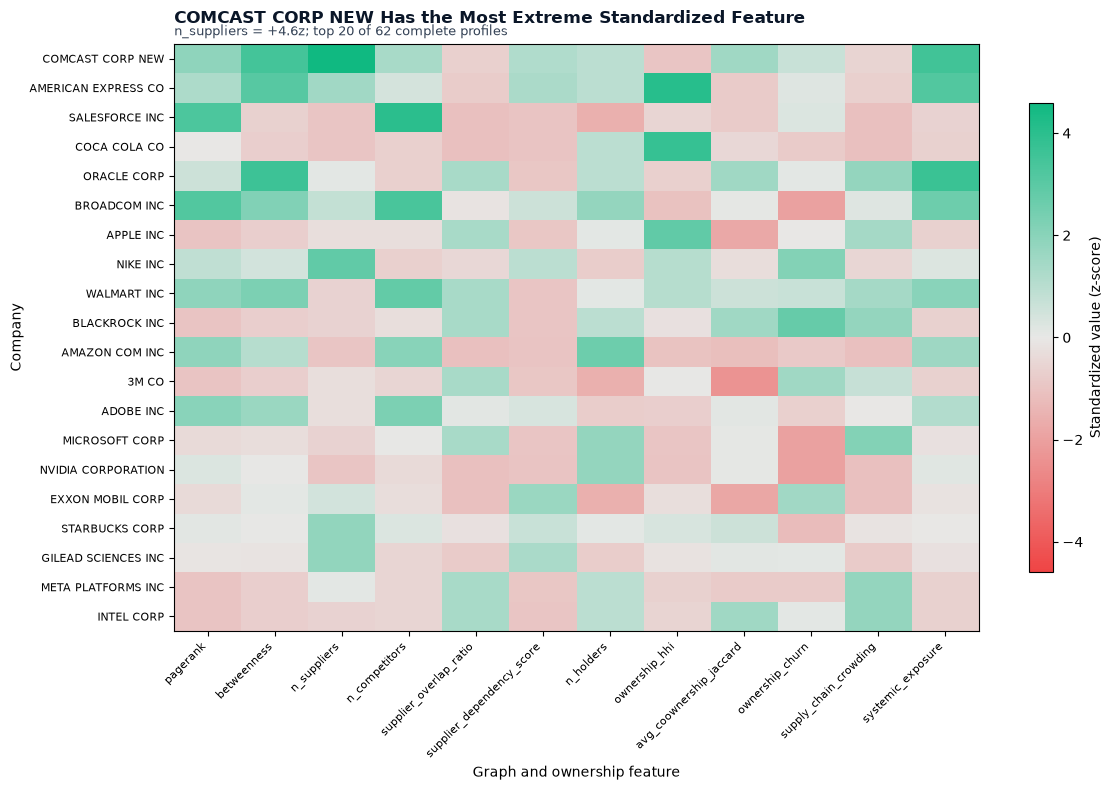

In [42]:
fig, ax = plt.subplots(figsize=(12, 8))
diverging_cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
image = ax.imshow(
    plot_data,
    aspect="auto",
    cmap=diverging_cmap,
    interpolation="nearest",
    vmin=-np.abs(plot_data).max(),
    vmax=np.abs(plot_data).max(),
)
ax.set_yticks(range(len(plot_entities)))
ax.set_yticklabels(plot_entities, fontsize=8)
ax.set_xticks(range(len(diagnostic_cols)))
ax.set_xticklabels(diagnostic_cols, fontsize=8, rotation=45, ha="right")
ax.set_xlabel("Graph and ownership feature")
ax.set_ylabel("Company")
add_message_title(
    ax,
    f"{plot_entities[extreme_row]} Has the Most Extreme Standardized Feature",
    subtitle=(
        f"{diagnostic_cols[extreme_col]} = {plot_data[extreme_row, extreme_col]:+.1f}z; "
        f"top 20 of {heatmap_frame.height} complete profiles"
    ),
)
fig.colorbar(image, ax=ax, shrink=0.8, label="Standardized value (z-score)")
fig.tight_layout()
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")
    fig.show()

**Finding**: The heatmap shows which companies are outliers on specific
graph features. Combining graph-derived columns (PageRank, betweenness) with
13F holdings columns (n_holders, ownership_hhi) produces an interaction
surface that single-source features cannot express; whether these
interactions add predictive value is not measured in this notebook.

## 12. Persist Outputs

In [43]:
FEATURE_METADATA = {
    "pagerank": {
        "category": "topology",
        "interpretation": "Graph centrality in the supply network",
    },
    "betweenness": {"category": "topology", "interpretation": "Bridge or bottleneck position"},
    "clustering": {"category": "topology", "interpretation": "Local neighborhood density"},
    "in_degree": {"category": "topology", "interpretation": "Incoming graph connections"},
    "out_degree": {"category": "topology", "interpretation": "Outgoing graph connections"},
    "n_suppliers": {"category": "supply", "interpretation": "Number of extracted suppliers"},
    "n_competitors": {"category": "supply", "interpretation": "Number of extracted competitors"},
    "n_customers": {"category": "supply", "interpretation": "Number of extracted customers"},
    "shared_supplier_count": {
        "category": "supply",
        "interpretation": "Suppliers shared with other covered companies",
    },
    "single_source_count": {
        "category": "supply",
        "interpretation": "Suppliers serving only one covered company",
    },
    "supplier_overlap_ratio": {
        "category": "supply",
        "interpretation": "Fraction of suppliers shared across firms",
    },
    "supplier_dependency_score": {
        "category": "supply",
        "interpretation": "Average inverse supplier diversification",
    },
}

Ownership metadata distinguishes measured point-in-time quantities from the
transparent candidate proxies used later.

In [44]:
FEATURE_METADATA.update(
    {
        "n_holders": {
            "category": "holdings",
            "interpretation": "Covered institutions holding the stock",
        },
        "crowding_score": {"category": "holdings", "interpretation": "Normalized holder count"},
        "top_holder_pct": {
            "category": "holdings",
            "interpretation": "Largest holder share of value",
        },
        "ownership_hhi": {"category": "holdings", "interpretation": "Ownership concentration"},
        "inst_coverage_pct": {
            "category": "holdings",
            "interpretation": "Coverage among sampled institutions",
        },
        "inst_value_change": {
            "category": "holdings",
            "interpretation": "Change in institutional value",
        },
        "inst_pct_change": {
            "category": "holdings",
            "interpretation": "Percent change in institutional value",
        },
        "avg_coownership_jaccard": {
            "category": "holdings",
            "interpretation": "Average holder overlap with matched peers",
        },
        "n_similar_stocks": {
            "category": "holdings",
            "interpretation": "Count of matched peers with high holder overlap",
        },
    }
)

Temporal fields separate the zero-baseline supply snapshot from vintage-aware
ownership history.

In [45]:
FEATURE_METADATA.update(
    {
        "relationship_churn": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "centrality_momentum": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "supplier_change": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "ownership_churn": {
            "category": "temporal",
            "interpretation": "1 − mean Jaccard of holder sets across consecutive 13F vintages",
        },
        "position_value_cv": {
            "category": "temporal",
            "interpretation": "Coefficient of variation of position value across 13F vintages",
        },
        "new_holders_recent": {
            "category": "temporal",
            "interpretation": "CIKs holding the stock in the latest vintage but absent from the prior vintage",
        },
    }
)

Cross-graph metadata describes each interaction algebraically without
implying measured causality or predictive value.

In [46]:
FEATURE_METADATA.update(
    {
        "supply_chain_crowding": {
            "category": "cross_graph",
            "interpretation": "Supplier-overlap ratio × normalized holder count",
        },
        "concentrated_dependency_risk": {
            "category": "cross_graph",
            "interpretation": "Supplier-dependency score × ownership HHI",
        },
        "systemic_exposure": {
            "category": "cross_graph",
            "interpretation": "Betweenness centrality × holder count",
        },
        "customer_concentration_risk": {
            "category": "cross_graph",
            "interpretation": "Customer count × top-holder value share",
        },
    }
)

In [47]:
all_features.write_parquet(OUTPUT_DIR / "features.parquet")
features_long = all_features.unpivot(
    index=["entity", "cusip", "issuer_name"],
    variable_name="feature_name",
    value_name="feature_value",
)
features_long.write_parquet(OUTPUT_DIR / "features_long.parquet")
pl.DataFrame(
    [{"feature_name": key, **value} for key, value in FEATURE_METADATA.items()]
).write_parquet(OUTPUT_DIR / "feature_metadata.parquet")
company_mapping.write_parquet(OUTPUT_DIR / "company_mapping.parquet")

print("Saved: features.parquet")
print("Saved: features_long.parquet")
print("Saved: feature_metadata.parquet")
print("Saved: company_mapping.parquet")

Saved: features.parquet
Saved: features_long.parquet
Saved: feature_metadata.parquet
Saved: company_mapping.parquet


## 13. Verification and Summary

In [48]:
print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)
print(f"Signed supply snapshot: {SUPPLY_GRAPH_COMMIT} ({SUPPLY_GRAPH_SHA256[:12]})")
print(f"Supply-chain companies processed: {len(source_companies)}")
print(f"Cross-graph matches: {len(matched_companies)}")
print(
    "Ambiguous issuer mappings: "
    f"{company_mapping.filter(pl.col('match_method') == 'ambiguous').height}"
)
print(f"Supply relationships: {len(supply_rel_df)}")
print(f"13F vintages through {CUTOFF_DATE}: {len(holdings_vintages)}")
print(f"Feature columns: {len(all_features.columns) - 3}")
print(f"Output target: {OUTPUT_DIR.name}")


NOTEBOOK EXECUTION COMPLETE
Signed supply snapshot: eacb181d (743c96ecea20)
Supply-chain companies processed: 127
Cross-graph matches: 72
Ambiguous issuer mappings: 8
Supply relationships: 1057
13F vintages through 2026-02-17: 3
Feature columns: 31
Output target: ch23_knowledge_graph_features


## Key Takeaways

1. Network topology features (PageRank, betweenness, clustering) capture
   structural importance and bottleneck risk that standalone entity
   attributes miss.
2. Point-in-time long-equity 13F features summarize holder breadth,
   concentration, and co-ownership; they are candidate crowding proxies, not
   measured price impact.
3. Cross-graph features combining supply-chain and ownership signals
   create transparent interaction terms for downstream testing.
4. The feature matrix is output in both wide format (ready for gradient
   boosting) and long format (convenient for IC analysis), with ambiguous
   issuer mappings preserved in a separate audit artifact.

**Next**: See `10_network_portfolio_construction.py` for network-based
portfolio construction and Section 23.4 for the full feature discussion.